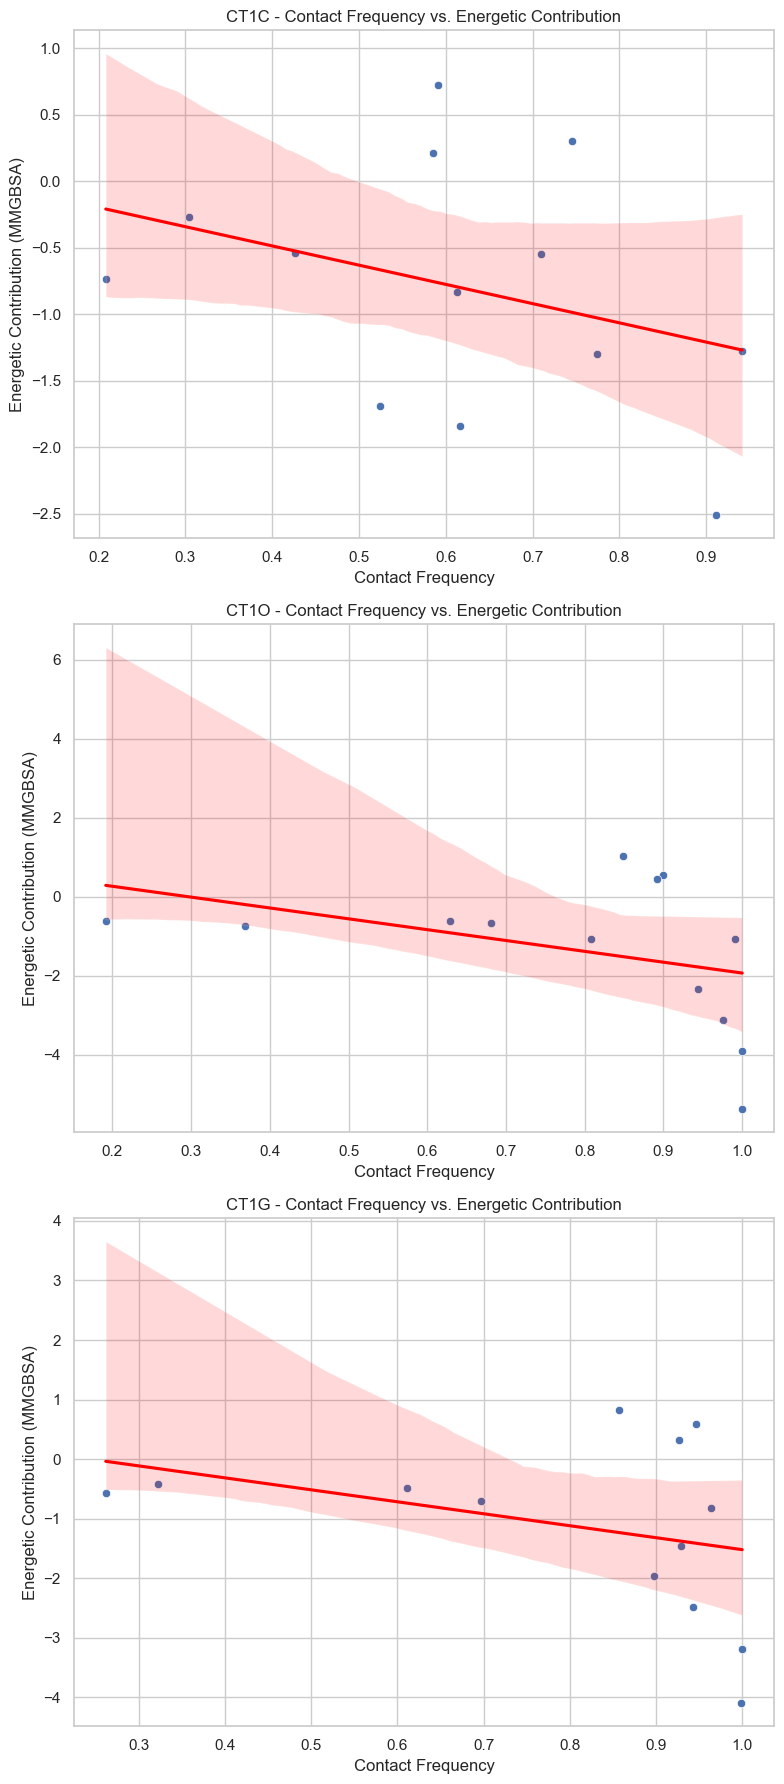

In [2]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Function to read contact frequency CSV file
def read_contact_freq(file_path):
    df = pd.read_csv(file_path)
    df.set_index('residue', inplace=True)
    return df

# Function to read energetic contributions CSV file
def read_energetic_contrib(file_path):
    df = pd.read_csv(file_path)
    df.set_index('residue', inplace=True)
    return df

# Paths to your CSV files
contact_freq_path = '/Users/chenyifang/Desktop/new_noWater.csv'
energetic_contrib_path = '/Users/chenyifang/Desktop/mmgbsa_500ns.csv'

# Read the dataframes
contact_df = read_contact_freq(contact_freq_path)
energetic_df = read_energetic_contrib(energetic_contrib_path)

# Ensure both dataframes have the same residues
common_residues = contact_df.index.intersection(energetic_df.index)
contact_df = contact_df.loc[common_residues]
energetic_df = energetic_df.loc[common_residues]

# Initialize a dictionary to store results
results = {'Ligand': [], 'Pearson correlation': [], 'Spearman correlation': []}

# Calculate Pearson and Spearman correlations
for ligand in contact_df.columns:
    if ligand in energetic_df.columns:
        x = contact_df[ligand]
        y = energetic_df[ligand]
        if len(x) > 1 and len(y) > 1:  # Check if there are at least two elements
            pearson_corr, _ = pearsonr(x, y)
            spearman_corr, _ = spearmanr(x, y)
            results['Ligand'].append(ligand)
            results['Pearson correlation'].append(pearson_corr)
            results['Spearman correlation'].append(spearman_corr)

# Convert results to a DataFrame for easier viewing
results_df = pd.DataFrame(results)

# Save the result to a new CSV file
results_df.to_csv('/Users/chenyifang/Desktop/correlation_results.csv', index=False)


# Plotting the relationship
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=len(contact_df.columns), ncols=1, figsize=(8, len(contact_df.columns) * 6))

for i, ligand in enumerate(contact_df.columns):
    if ligand in energetic_df.columns:
        x = contact_df[ligand]
        y = energetic_df[ligand]
        if len(x) > 1 and len(y) > 1:
            ax = axes[i] if len(contact_df.columns) > 1 else axes
            sns.scatterplot(x=x, y=y, ax=ax)
            sns.regplot(x=x, y=y, scatter=False, ax=ax, color='red')
            ax.set_title(f'{ligand} - Contact Frequency vs. Energetic Contribution')
            ax.set_xlabel('Contact Frequency')
            ax.set_ylabel('Energetic Contribution (MMGBSA)')

plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/RA/SLC6A8/contact_freq_vs_energetic_contrib.png', dpi=300, bbox_inches='tight')
plt.show()


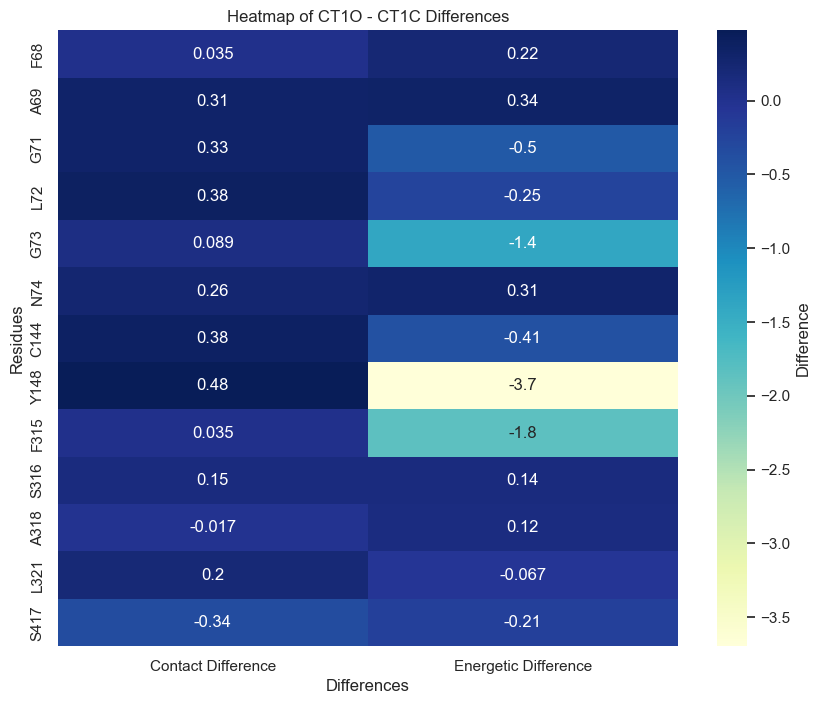

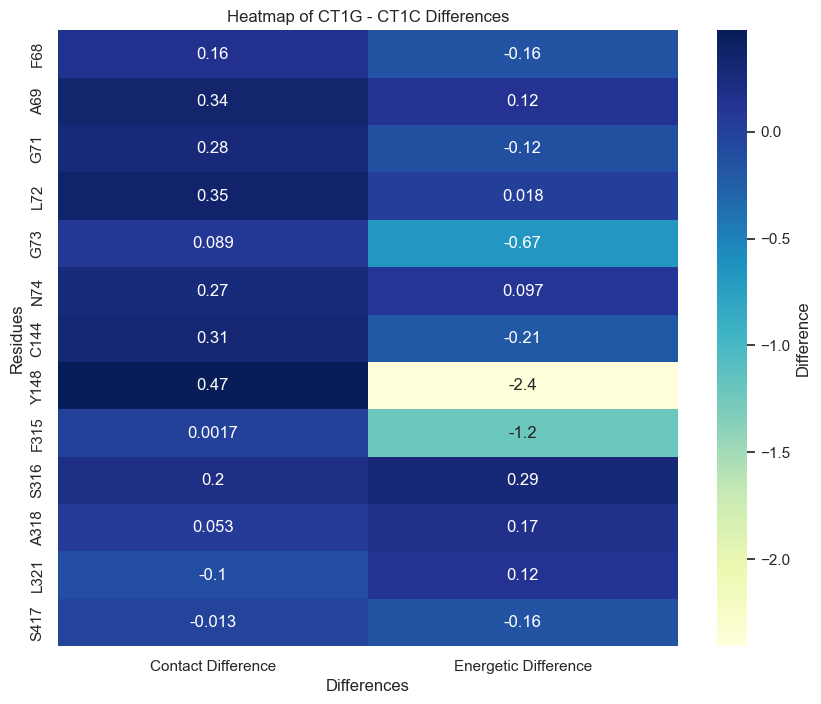

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to read contact frequency CSV file
def read_contact_freq(file_path):
    df = pd.read_csv(file_path)
    df.set_index('residue', inplace=True)
    return df

# Function to read energetic contributions CSV file
def read_energetic_contrib(file_path):
    df = pd.read_csv(file_path)
    df.set_index('residue', inplace=True)
    return df

# Paths to your CSV files
contact_freq_path = '/Users/chenyifang/Desktop/new_noWater.csv'
energetic_contrib_path = '/Users/chenyifang/Desktop/mmgbsa_500ns.csv'

# Read the dataframes
contact_df = read_contact_freq(contact_freq_path)
energetic_df = read_energetic_contrib(energetic_contrib_path)

# Ensure both dataframes have the same residues
common_residues = contact_df.index.intersection(energetic_df.index)
contact_df = contact_df.loc[common_residues]
energetic_df = energetic_df.loc[common_residues]

# Calculate differences for contact frequencies
contact_diff_C_O = contact_df['CT1O'] - contact_df['CT1C']
contact_diff_C_G = contact_df['CT1G'] - contact_df['CT1C']

# Calculate differences for energetic contributions
energetic_diff_C_O = energetic_df['CT1O'] - energetic_df['CT1C']
energetic_diff_C_G = energetic_df['CT1G'] - energetic_df['CT1C']

# Combine the differences into dataframes
contact_diff_df = pd.DataFrame({
    'residue': common_residues,
    'CT1O - CT1C': contact_diff_C_O,
    'CT1G - CT1C': contact_diff_C_G
}).reset_index(drop=True)

energetic_diff_df = pd.DataFrame({
    'residue': common_residues,
    'CT1O - CT1C': energetic_diff_C_O,
    'CT1G - CT1C': energetic_diff_C_G
}).reset_index(drop=True)

# Create a combined DataFrame for heatmap plotting
combined_diff_C_O = pd.DataFrame({
    'Contact Difference': contact_diff_C_O,
    'Energetic Difference': energetic_diff_C_O
})

combined_diff_C_G = pd.DataFrame({
    'Contact Difference': contact_diff_C_G,
    'Energetic Difference': energetic_diff_C_G
})

# Plotting the heatmap for CT1O - CT1C
plt.figure(figsize=(10, 8))
sns.heatmap(combined_diff_C_O, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Difference'})
plt.title('Heatmap of CT1O - CT1C Differences')
plt.xlabel('Differences')
plt.ylabel('Residues')
plt.xticks(ticks=[0.5, 1.5], labels=['Contact Difference', 'Energetic Difference'])
#plt.savefig('/path/to/heatmap_CT1O_CT1C.png')
plt.show()

# Plotting the heatmap for CT1G - CT1C
plt.figure(figsize=(10, 8))
sns.heatmap(combined_diff_C_G, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Difference'})
plt.title('Heatmap of CT1G - CT1C Differences')
plt.xlabel('Differences')
plt.ylabel('Residues')
plt.xticks(ticks=[0.5, 1.5], labels=['Contact Difference', 'Energetic Difference'])
#plt.savefig('/path/to/heatmap_CT1G_CT1C.png')
plt.show()


/var/folders/6g/sb2r7d4n379gcm6jc9q5njlr0000gn/T/ipykernel_1541/3074758348.py:34: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=contact_diff_df['CT1O - CT1C'], y=energetic_diff_df['CT1O - CT1C'], cmap="YlOrBr", shade=True)


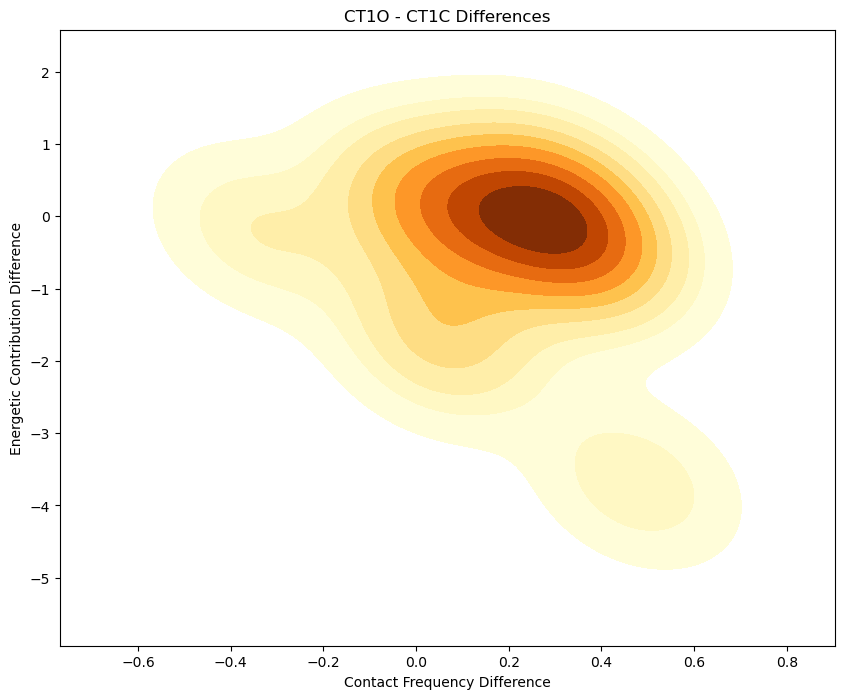

/var/folders/6g/sb2r7d4n379gcm6jc9q5njlr0000gn/T/ipykernel_1541/3074758348.py:43: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=contact_diff_df['CT1G - CT1C'], y=energetic_diff_df['CT1G - CT1C'], cmap="YlOrBr", shade=True)


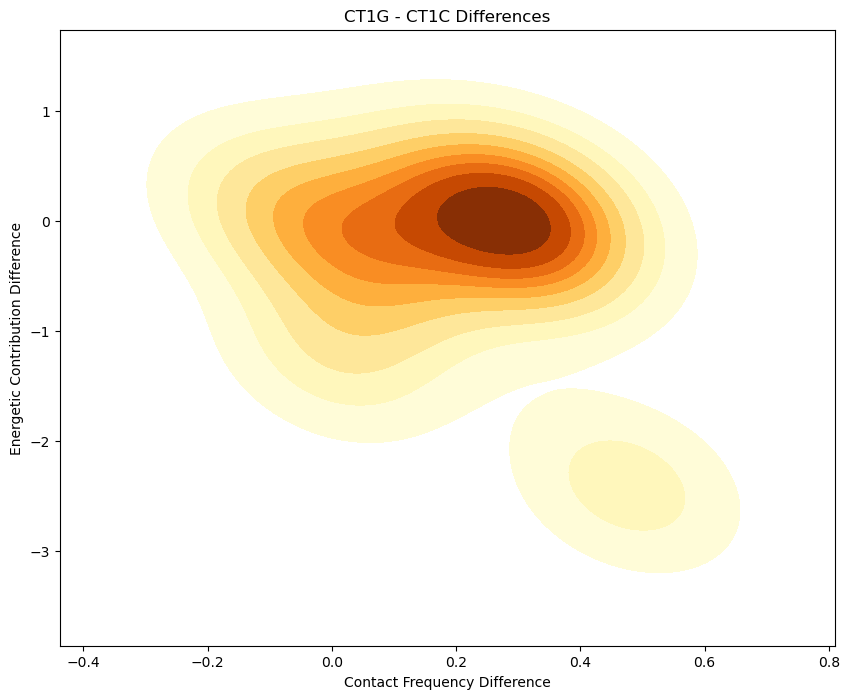

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read contact frequency CSV file
contact_freq_df = pd.read_csv('/Users/chenyifang/Desktop/new_noWater.csv')
contact_freq_df.set_index('residue', inplace=True)

# Read energetic contributions CSV file
energetic_contrib_df = pd.read_csv('/Users/chenyifang/Desktop/mmgbsa_500ns.csv')
energetic_contrib_df.set_index('residue', inplace=True)

# Calculate differences for contact frequencies
contact_diff_C_O = contact_freq_df['CT1O'] - contact_freq_df['CT1C']
contact_diff_C_G = contact_freq_df['CT1G'] - contact_freq_df['CT1C']

# Calculate differences for energetic contributions
energetic_diff_C_O = energetic_contrib_df['CT1O'] - energetic_contrib_df['CT1C']
energetic_diff_C_G = energetic_contrib_df['CT1G'] - energetic_contrib_df['CT1C']

# Combine the differences into dataframes
contact_diff_df = pd.DataFrame({
    'CT1O - CT1C': contact_diff_C_O,
    'CT1G - CT1C': contact_diff_C_G
})

energetic_diff_df = pd.DataFrame({
    'CT1O - CT1C': energetic_diff_C_O,
    'CT1G - CT1C': energetic_diff_C_G
})

# Plotting the heatmap (KDE plot) for CT1O - CT1C
plt.figure(figsize=(10, 8))
sns.kdeplot(x=contact_diff_df['CT1O - CT1C'], y=energetic_diff_df['CT1O - CT1C'], cmap="YlOrBr", shade=True)
plt.title('CT1O - CT1C Differences')
plt.xlabel('Contact Frequency Difference')
plt.ylabel('Energetic Contribution Difference')
#plt.savefig('/path/to/KDE_CT1O_CT1C.png')
plt.show()

# Plotting the heatmap (KDE plot) for CT1G - CT1C
plt.figure(figsize=(10, 8))
sns.kdeplot(x=contact_diff_df['CT1G - CT1C'], y=energetic_diff_df['CT1G - CT1C'], cmap="YlOrBr", shade=True)
plt.title('CT1G - CT1C Differences')
plt.xlabel('Contact Frequency Difference')
plt.ylabel('Energetic Contribution Difference')
#plt.savefig('/path/to/KDE_CT1G_CT1C.png')
plt.show()


/var/folders/6g/sb2r7d4n379gcm6jc9q5njlr0000gn/T/ipykernel_4361/2535403410.py:40: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=diff_df['contact_diff_C_O'], y=diff_df['energetic_diff_C_O'], cmap="Blues", shade=True, ax=axs[0])
/var/folders/6g/sb2r7d4n379gcm6jc9q5njlr0000gn/T/ipykernel_4361/2535403410.py:48: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=diff_df['contact_diff_C_G'], y=diff_df['energetic_diff_C_G'], cmap="Reds", shade=True, ax=axs[1])


<Figure size 1000x800 with 0 Axes>

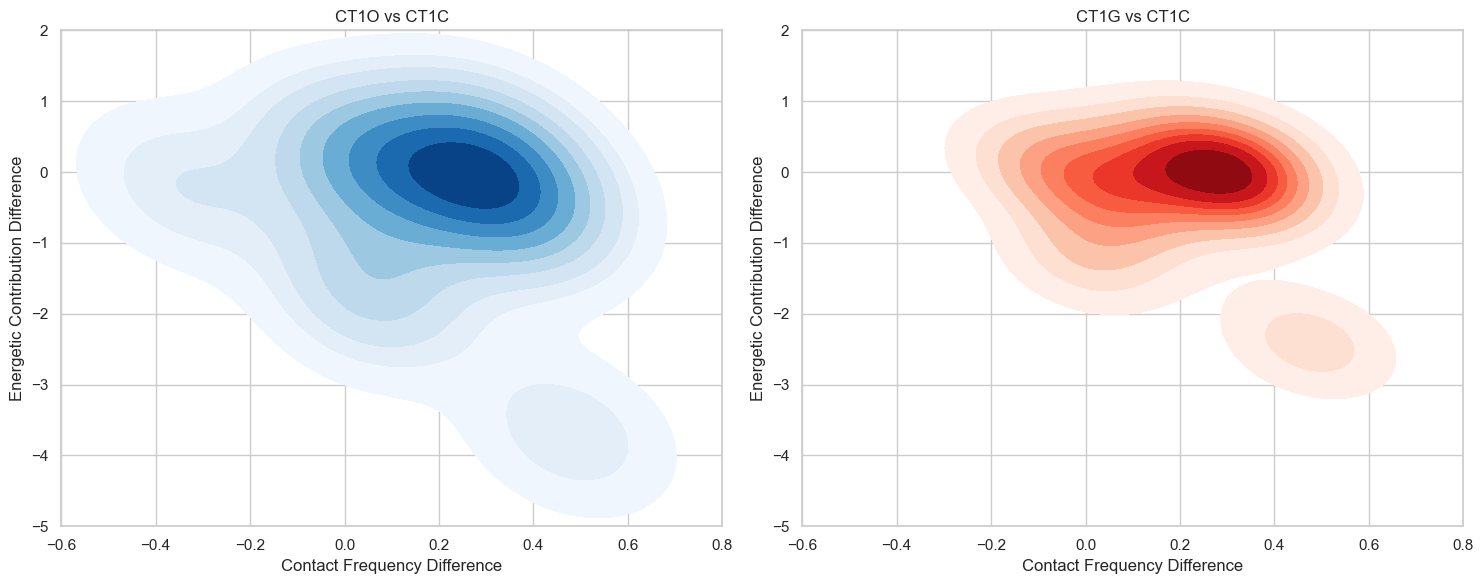

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read contact frequency CSV file
contact_freq_df = pd.read_csv('/Users/chenyifang/Desktop/new_noWater.csv')
contact_freq_df.set_index('residue', inplace=True)

# Read energetic contributions CSV file
energetic_contrib_df = pd.read_csv('/Users/chenyifang/Desktop/mmgbsa_500ns.csv')
energetic_contrib_df.set_index('residue', inplace=True)

# Calculate differences for contact frequencies
contact_diff_C_O = contact_freq_df['CT1O'] - contact_freq_df['CT1C']
contact_diff_C_G = contact_freq_df['CT1G'] - contact_freq_df['CT1C']

# Calculate differences for energetic contributions
energetic_diff_C_O = energetic_contrib_df['CT1O'] - energetic_contrib_df['CT1C']
energetic_diff_C_G = energetic_contrib_df['CT1G'] - energetic_contrib_df['CT1C']

# Create a dataframe to hold the differences
diff_df = pd.DataFrame({
    'contact_diff_C_O': contact_diff_C_O,
    'contact_diff_C_G': contact_diff_C_G,
    'energetic_diff_C_O': energetic_diff_C_O,
    'energetic_diff_C_G': energetic_diff_C_G
}).dropna()

# Define specific ranges for x and y axes
xlim = (-0.6, 0.8)  # Example range for x-axis
ylim = (-5.0, 2.0)  # Example range for y-axis

# Plotting the heatmap
plt.figure(figsize=(10, 8))

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plot CT1O - CT1C differences
sns.kdeplot(x=diff_df['contact_diff_C_O'], y=diff_df['energetic_diff_C_O'], cmap="Blues", shade=True, ax=axs[0])
axs[0].set_title('CT1O vs CT1C')
axs[0].set_xlabel('Contact Frequency Difference')
axs[0].set_ylabel('Energetic Contribution Difference')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)

# Plot CT1G - CT1C differences
sns.kdeplot(x=diff_df['contact_diff_C_G'], y=diff_df['energetic_diff_C_G'], cmap="Reds", shade=True, ax=axs[1])
axs[1].set_title('CT1G vs CT1C')
axs[1].set_xlabel('Contact Frequency Difference')
axs[1].set_ylabel('Energetic Contribution Difference')
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)

# Adjust layout
plt.tight_layout()

plt.savefig('/Users/chenyifang/Desktop/RA/SLC6A8/difference_profiles.png', dpi=300, bbox_inches='tight')
plt.show()


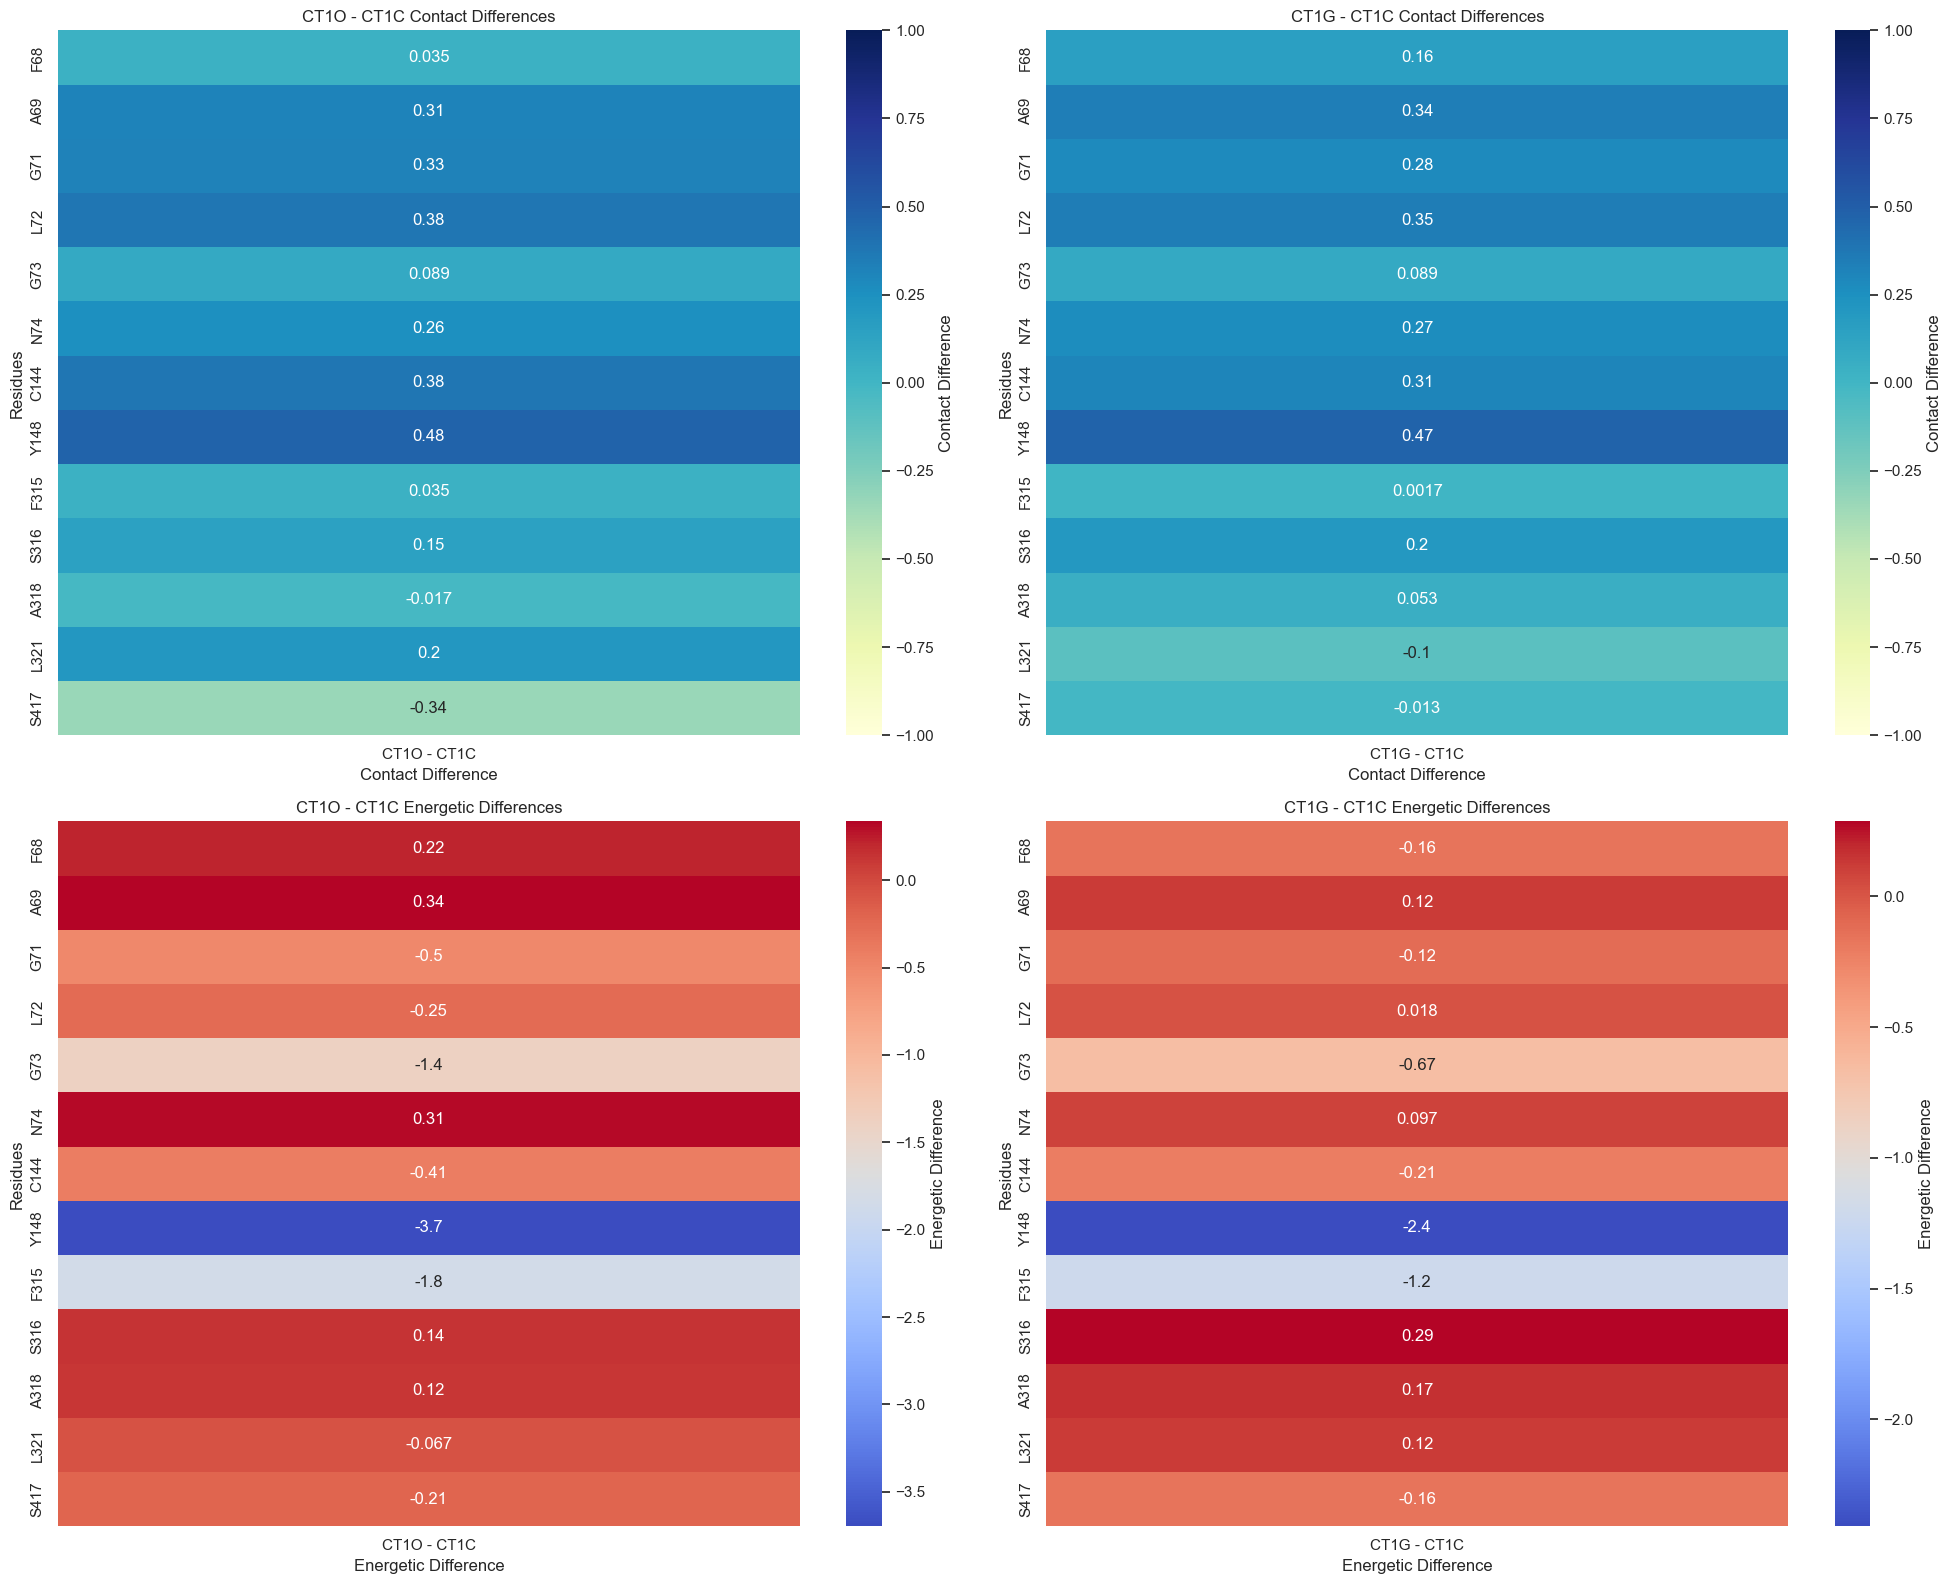

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to read contact frequency CSV file
def read_contact_freq(file_path):
    df = pd.read_csv(file_path)
    df.set_index('residue', inplace=True)
    return df

# Function to read energetic contributions CSV file
def read_energetic_contrib(file_path):
    df = pd.read_csv(file_path)
    df.set_index('residue', inplace=True)
    return df

# Paths to your CSV files
contact_freq_path = '/Users/chenyifang/Desktop/new_noWater.csv'
energetic_contrib_path = '/Users/chenyifang/Desktop/mmgbsa_500ns.csv'

# Read the dataframes
contact_df = read_contact_freq(contact_freq_path)
energetic_df = read_energetic_contrib(energetic_contrib_path)

# Ensure both dataframes have the same residues
common_residues = contact_df.index.intersection(energetic_df.index)
contact_df = contact_df.loc[common_residues]
energetic_df = energetic_df.loc[common_residues]

# Calculate differences for contact frequencies
contact_diff_C_O = contact_df['CT1O'] - contact_df['CT1C']
contact_diff_C_G = contact_df['CT1G'] - contact_df['CT1C']

# Calculate differences for energetic contributions
energetic_diff_C_O = energetic_df['CT1O'] - energetic_df['CT1C']
energetic_diff_C_G = energetic_df['CT1G'] - energetic_df['CT1C']

# Combine the differences into dataframes
contact_diff_df = pd.DataFrame({
    'residue': common_residues,
    'CT1O - CT1C': contact_diff_C_O,
    'CT1G - CT1C': contact_diff_C_G
}).reset_index(drop=True)

energetic_diff_df = pd.DataFrame({
    'residue': common_residues,
    'CT1O - CT1C': energetic_diff_C_O,
    'CT1G - CT1C': energetic_diff_C_G
}).reset_index(drop=True)

# Plotting all heatmaps in a single figure
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Heatmap for CT1O - CT1C Contact Differences
sns.heatmap(contact_diff_df.set_index('residue')[['CT1O - CT1C']], annot=True, cmap='YlGnBu', cbar_kws={'label': 'Contact Difference'}, vmax=1, vmin=-1, ax=axes[0, 0])
axes[0, 0].set_title('CT1O - CT1C Contact Differences')
axes[0, 0].set_xlabel('Contact Difference')
axes[0, 0].set_ylabel('Residues')

# Heatmap for CT1G - CT1C Contact Differences
sns.heatmap(contact_diff_df.set_index('residue')[['CT1G - CT1C']], annot=True, cmap='YlGnBu', cbar_kws={'label': 'Contact Difference'}, vmax=1, vmin=-1, ax=axes[0, 1])
axes[0, 1].set_title('CT1G - CT1C Contact Differences')
axes[0, 1].set_xlabel('Contact Difference')
axes[0, 1].set_ylabel('Residues')

# Heatmap for CT1O - CT1C Energetic Differences
sns.heatmap(energetic_diff_df.set_index('residue')[['CT1O - CT1C']], annot=True, cmap='coolwarm', cbar_kws={'label': 'Energetic Difference'}, ax=axes[1, 0])
axes[1, 0].set_title('CT1O - CT1C Energetic Differences')
axes[1, 0].set_xlabel('Energetic Difference')
axes[1, 0].set_ylabel('Residues')

# Heatmap for CT1G - CT1C Energetic Differences
sns.heatmap(energetic_diff_df.set_index('residue')[['CT1G - CT1C']], annot=True, cmap='coolwarm', cbar_kws={'label': 'Energetic Difference'}, ax=axes[1, 1])
axes[1, 1].set_title('CT1G - CT1C Energetic Differences')
axes[1, 1].set_xlabel('Energetic Difference')
axes[1, 1].set_ylabel('Residues')
plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/RA/SLC6A8/difference_profiles_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
